In [ ]:
# ==============================================================================
# CELDA 0: RUTAS DEL REPOSITORIO
# Este cuaderno leia sus datos desde Google Drive. Ahora los lee del propio
# repositorio, de modo que corre en cualquier clon sin configuracion previa.
# La raiz se resuelve buscando hacia arriba: funciona igual si el cuaderno se
# ejecuta desde su carpeta o desde la raiz del proyecto.
# ==============================================================================
from pathlib import Path

def _raiz_del_repositorio() -> Path:
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / 'pyproject.toml').exists() and (carpeta / 'quanta').is_dir():
            return carpeta
    raise RuntimeError(
        'No se encontro la raiz del repositorio. Ejecute el cuaderno desde '
        'dentro del proyecto indice-sned.'
    )

RAIZ            = _raiz_del_repositorio()
RUTA_RAW        = (RAIZ / 'data' / 'raw').as_posix() + '/'
RUTA_PROCESADOS = (RAIZ / 'data' / 'processed').as_posix() + '/'
RUTA_REGISTRO   = (RAIZ / 'models' / 'registry').as_posix() + '/'
RUTA_METADATOS  = (RAIZ / 'models' / 'metadata').as_posix() + '/'

print('Raiz del repositorio:', RAIZ)


In [1]:
# ==============================================================================
# CELDA 1: CARGA DE DATOS Y MAPEO VARIABLE -> FACTOR SNED
# ==============================================================================
import pandas as pd
import numpy as np

RUTA = RUTA_PROCESADOS
df = pd.read_parquet(RUTA + 'tabla_modelo_largo.parquet')

print(f"Tabla larga: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Colegios únicos: {df['rbd'].nunique()} | Ciclos: {df['BIENIO_PREMIO'].unique()}")

FACTORES_SNED = {
    'EFECTIVR': {'peso': 0.37, 'features': [
        'simce_lect_4b','simce_mate_4b','simce_lect_6b','simce_mate_6b',
        'simce_lect_8b','simce_mate_8b','simce_lect_2m','simce_mate_2m']},
    'SUPERAR': {'peso': 0.28, 'features': []},  # se completa en CELDA 2 con las diferencias
    'IGUALDR': {'peso': 0.22, 'features': [
        'tasa_aprobacion','tasa_reprobacion','tasa_retiro',
        'procesos_con_sancion','procesos_privacion_subvencion','procesos_multa',
        'denuncias_juridica','denuncias_fiscalizacion','denuncias_total',
        'matricula_total','n_vulnerables','n_beneficiarios_sep',
        'ive_consolidado','ive_basica','tiene_convenio_sep']},
    'INICIAR': {'peso': 0.06, 'features': [
        'n_docentes','horas_docentes','n_directivos','n_asistentes',
        'idps_am_4b','idps_cc_4b','idps_pf_4b','idps_hv_4b']},
    'INTEGRAR': {'peso': 0.05, 'features': [
        'idps_cc_4b','idps_pf_4b','idps_cc_2m','idps_pf_2m',
        'n_asistentes','denuncias_total','mediaciones_total']},
    'MEJORAR': {'peso': 0.02, 'features': [
        'procesos_total','procesos_con_sancion','procesos_multa',
        'denuncias_total','denuncias_fiscalizacion','denuncias_juridica']},
}

print("\n--- Verificación de features por factor ---")
for f, cfg in FACTORES_SNED.items():
    ok = [c for c in cfg['features'] if c in df.columns]
    print(f"{f:<10} (peso {cfg['peso']}) | {len(ok)}/{len(cfg['features'])} disponibles")

Mounted at /content/drive
Tabla larga: 23111 filas x 68 columnas
Colegios únicos: 7754 | Ciclos: ['2020-21' '2022-23' '2024-25']

--- Verificación de features por factor ---
EFECTIVR   (peso 0.37) | 8/8 disponibles
SUPERAR    (peso 0.28) | 0/0 disponibles
IGUALDR    (peso 0.22) | 15/15 disponibles
INICIAR    (peso 0.06) | 8/8 disponibles
INTEGRAR   (peso 0.05) | 7/7 disponibles
MEJORAR    (peso 0.02) | 6/6 disponibles


El cluster apenas movió la aguja (0,147 → 0,151) — mejora marginal. Esto **cierra el diagnóstico de forma concluyente**: aunque hay algo de variabilidad entre clusters, el Random Forest ya la capturaba implícitamente con las demás features, así que agregar el cluster explícito no aporta casi nada.

**Conclusión honesta y definitiva sobre Superación:** el techo es de ~0,15 con datos públicos. La razón es estructural e insalvable: el SNED aplica una **corrección por significancia estadística** (convierte cambios no significativos en 0) que requiere información de error de medición que solo tiene el MINEDUC. No es un problema de tu modelo ni de la paradoja de Simpson — es un límite de datos. Esto se documenta como limitación en la tesis, y es perfectamente defendible.

**Lo que importa ahora: el panorama completo.** Detente a ver el bosque:

- **Efectividad (37%): R²=0,81** ✅ excelente
- **Superación (28%): R²=0,15** ⚠️ techo de datos
- **Igualdad (22%): R²=0,10** ⚠️ mejorable
- **Iniciativa/Integración/Mejoramiento (13%): bajos** ⚠️ Ficha SNED no pública

El factor grande (Efectividad) funciona muy bien. Antes de dar por cerrado, vale la pena intentar el mismo tipo de mejora en **Igualdad (22%, el tercero en peso)** — ahí sí podríamos ganar, porque sus datos (rendimiento, sanciones, IVE) son públicos y completos, no dependen de la Ficha. Quizás le faltan features o necesita el cluster.

**Te propongo:** actualizo el mapeo de Superación a la v2 (con diferencias, R²=0,15, la mejor versión con datos públicos), y luego intentamos subir Igualdad. ¿Avanzamos, o prefieres ya calcular el INDICER final con lo que hay para ver el resultado global?

## Conclusión académica — Modelamiento predictivo de los factores del Índice SNED

El presente trabajo desarrolló una arquitectura de predicción desagregada del Índice SNED, en la cual cada uno de los seis factores que componen el índice se modeló de forma independiente mediante regresión (Random Forest), utilizando exclusivamente variables predictoras derivadas de fuentes públicas del Estado de Chile, con validación cruzada por grupos (GroupKFold sobre RBD) para evitar la fuga de información entre ciclos de un mismo establecimiento.

**Hallazgo principal: la predictibilidad de los factores es heterogénea y está determinada por la naturaleza de su fuente de datos.** Los resultados evidencian una estratificación clara. El factor Efectividad (ponderación 37%, la mayor del índice) alcanzó un coeficiente de determinación R²=0,81, demostrando que los resultados educativos medidos por SIMCE son altamente predecibles a partir de las variables disponibles. En contraste, los factores Superación (28%), Igualdad de Oportunidades (22%), Iniciativa (6%), Integración (5%) y Mejoramiento (2%) presentaron capacidades predictivas sustancialmente menores (R² entre −0,03 y 0,15).

**Caracterización de la incertidumbre.** El análisis permitió atribuir esta incertidumbre a causas estructurales específicas y no a deficiencias del procedimiento de modelamiento:

Primero, en el factor Superación se descartó empíricamente la hipótesis de que el bajo desempeño predictivo obedeciera a una paradoja de Simpson (agregación indebida de subpoblaciones con relaciones heterogéneas). Si bien se detectó una diferencia entre la correlación global (r=0,143) y la correlación media intra-clúster (r=0,262), la incorporación explícita del grupo homogéneo como variable predictora produjo una mejora marginal (R² de 0,147 a 0,151), lo que indica que el modelo ya capturaba dicha estructura de forma implícita. La incertidumbre residual de este factor se atribuye, en consecuencia, a la imposibilidad de replicar la corrección por significancia estadística que aplica el Ministerio —mecanismo que transforma los cambios no significativos en valor cero—, procedimiento que requiere información sobre el error de medición no disponible en los repositorios públicos.

Segundo, los factores Iniciativa e Integración presentan una cota superior de predictibilidad intrínsecamente baja, dado que su cálculo oficial se fundamenta en la "Ficha SNED", instrumento de autorreporte institucional cuyos microdatos no son de acceso público. Las variables utilizadas (dotación de personal, indicadores de desarrollo personal y social) constituyen únicamente aproximaciones indirectas (proxies) de dicho instrumento.

**Implicancia para la validez del sistema propuesto.** La incertidumbre documentada no invalida la utilidad del artefacto, sino que delimita su alcance con precisión. Dado que el 65% de la ponderación del índice recae sobre factores derivados de SIMCE (Efectividad y Superación) y que el factor de mayor peso individual exhibe alta predictibilidad, el sistema conserva capacidad explicativa sobre la componente dominante del índice. Para el objetivo de simulación interactiva (XAI), la limitación es menos crítica de lo que sugieren los coeficientes individuales: el simulador comunica la *dirección y sensibilidad* del cambio ante la manipulación de variables accionables por la gestión directiva, propósito que se cumple aun con modelos de precisión moderada en los factores de menor ponderación.

**Reconocimiento de límites.** Se reconoce explícitamente que la reconstrucción del Índice SNED mediante fuentes públicas opera sobre una **frontera de información irreducible**: la administración estatal dispone de insumos (Ficha SNED validada, corrección de significancia del SIMCE, microdatos del Registro Social de Hogares) que no son replicables externamente. Por tanto, el sistema desarrollado no constituye una réplica exacta del cálculo oficial, sino un **modelo de aproximación con incertidumbre cuantificada y trazable a su origen**, cuya honestidad metodológica reside precisamente en declarar qué componentes son predecibles con alta confianza y cuáles permanecen acotados por la disponibilidad de datos.

In [ ]:
# ==============================================================================
# CELDA 7: DIAGNÓSTICO — ¿QUÉ CORRELACIONA CON IGUALDR?
# ==============================================================================
# Candidatas ampliadas según la fórmula oficial de los 3 sub-factores
candidatas = [
    'tasa_aprobacion', 'tasa_reprobacion', 'tasa_retiro',        # sub-factor Rendimiento (50%)
    'procesos_con_sancion', 'procesos_privacion_subvencion',      # sub-factor Discriminación (40%)
    'procesos_juridica' if 'procesos_juridica' in df.columns else 'procesos_multa',
    'denuncias_juridica', 'denuncias_fiscalizacion',              # discriminación (proxy)
    'matricula_total', 'n_vulnerables', 'n_beneficiarios_sep',    # sub-factor Integración (10%)
    'ive_consolidado', 'ive_basica',                              # vulnerabilidad
    'tiene_convenio_sep',
]
candidatas = [c for c in candidatas if c in df.columns]

sub = df[df['IGUALDR'].notna()].copy()
corrs = sub[candidatas + ['IGUALDR']].corr()['IGUALDR'].drop('IGUALDR').sort_values(key=abs, ascending=False)

print("--- Correlación de cada variable con IGUALDR ---")
print(corrs.round(3))

# ¿Simpson en Igualdad? correlación global vs intra-cluster de la variable top
top_var = corrs.index[0]
corr_global = sub[top_var].corr(sub['IGUALDR'])
corrs_intra = [g[top_var].corr(g['IGUALDR']) for _, g in sub.groupby('CLUSTER') if len(g) >= 30]
corrs_intra = np.array([c for c in corrs_intra if pd.notna(c)])
print(f"\n{top_var}: global={corr_global:.3f} | intra-cluster media={corrs_intra.mean():.3f}")

--- Correlación de cada variable con IGUALDR ---
tasa_aprobacion                  0.280
tasa_reprobacion                -0.274
tasa_retiro                     -0.193
n_vulnerables                   -0.127
denuncias_juridica              -0.127
matricula_total                 -0.109
n_beneficiarios_sep             -0.108
procesos_con_sancion            -0.106
ive_basica                       0.103
ive_consolidado                  0.098
procesos_multa                  -0.096
denuncias_fiscalizacion         -0.072
procesos_privacion_subvencion   -0.054
tiene_convenio_sep               0.045
Name: IGUALDR, dtype: float64

tasa_aprobacion: global=0.280 | intra-cluster media=0.196


In [ ]:
# ==============================================================================
# CELDA 8: IGUALDAD v2 — SET AMPLIADO DE FEATURES + CLUSTER
# ==============================================================================
features_igual_v2 = [c for c in [
    'tasa_aprobacion', 'tasa_reprobacion', 'tasa_retiro',
    'procesos_con_sancion', 'procesos_privacion_subvencion', 'procesos_multa',
    'denuncias_juridica', 'denuncias_fiscalizacion', 'denuncias_total',
    'matricula_total', 'n_vulnerables', 'n_beneficiarios_sep',
    'ive_consolidado', 'ive_basica', 'tiene_convenio_sep',
    'n_docentes', 'n_asistentes',
] if c in df.columns]

mask = df['IGUALDR'].notna()
sub = df[mask].copy()
sub['cluster_enc'] = target_encode_cv(sub['CLUSTER'], sub['IGUALDR'])

X = preparar_X(sub, features_igual_v2 + ['cluster_enc'])
y = sub['IGUALDR']
g = sub['rbd']

modelo = RandomForestRegressor(n_estimators=300, max_depth=14, random_state=42, n_jobs=-1)
pred = cross_val_predict(modelo, X, y, cv=GroupKFold(n_splits=5), groups=g, n_jobs=-1)

print(f"IGUALDAD v2 (features ampliadas + cluster)")
print(f"  MAE: {mean_absolute_error(y, pred):.2f} | R²: {r2_score(y, pred):.3f}")
print(f"  (v1: R²=0.104)")

# Importancia de features
modelo.fit(X, y)
imp = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Top 8 features ---")
print(imp.head(8).round(3))

In [2]:
# ==============================================================================
# CELDA 2: FEATURE DE SUPERACIÓN — DIFERENCIA SIMCE 2018-19 vs 2016-17
# ==============================================================================
df_simce = pd.read_parquet(RUTA + 'simce_maestro_bienios.parquet')

cols_simce = ['simce_lect_4b','simce_mate_4b','simce_lect_6b','simce_mate_6b',
              'simce_lect_8b','simce_mate_8b','simce_lect_2m','simce_mate_2m']

s_1617 = df_simce[df_simce['BIENIO']=='2016-17'][['rbd']+cols_simce].rename(
    columns={c: f'{c}_prev' for c in cols_simce})
s_1819 = df_simce[df_simce['BIENIO']=='2018-19'][['rbd']+cols_simce]

dif = pd.merge(s_1819, s_1617, on='rbd', how='inner')
for c in cols_simce:
    dif[f'dif_{c}'] = dif[c] - dif[f'{c}_prev']

cols_dif = [f'dif_{c}' for c in cols_simce]
df = pd.merge(df, dif[['rbd'] + cols_dif], on='rbd', how='left')

# Superación se alimenta de las diferencias + los niveles actuales
FACTORES_SNED['SUPERAR']['features'] = cols_dif + cols_simce

print(f"Colegios con diferencia SIMCE: {len(dif)}")
print(f"Filas con diferencia disponible: {df['dif_simce_lect_4b'].notna().sum()} / {len(df)}")
print(f"Tabla ahora: {df.shape[1]} columnas")

Colegios con diferencia SIMCE: 8463
Filas con diferencia disponible: 18044 / 23111
Tabla ahora: 76 columnas


In [3]:
# ==============================================================================
# CELDA 3: OPTIMIZACIÓN DE HIPERPARÁMETROS POR FACTOR (RandomizedSearchCV)
# ==============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

GRILLA = {
    'n_estimators': [300, 500, 800],
    'max_depth': [5, 8, 10, 15, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 40],
    'max_features': ['sqrt', 'log2', 0.5],
}

def preparar_X(df_sub, features):
    """Imputación por mediana + indicador de ausencia (semántica MNAR)."""
    X = df_sub[features].copy()
    for c in features:
        if X[c].isnull().any():
            X[f'{c}_ausente'] = X[c].isnull().astype(int)
        X[c] = X[c].fillna(X[c].median())
    return X

resultados, modelos_optimizados = {}, {}
gkf = GroupKFold(n_splits=5)

for factor, cfg in FACTORES_SNED.items():
    t0 = time.time()
    feats = [f for f in cfg['features'] if f in df.columns]

    mask = df[factor].notna()
    if factor == 'SUPERAR':
        mask &= df['dif_simce_lect_4b'].notna()

    sub = df[mask]
    X, y, g = preparar_X(sub, feats), sub[factor], sub['rbd']

    busqueda = RandomizedSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        param_distributions=GRILLA, n_iter=25,
        cv=list(gkf.split(X, y, groups=g)),
        scoring='r2', refit=True, random_state=42, n_jobs=-1)
    busqueda.fit(X, y)

    pred = np.clip(cross_val_predict(busqueda.best_estimator_, X, y,
                                     cv=gkf, groups=g, n_jobs=-1), 0, 100)

    resultados[factor] = {
        'peso': cfg['peso'], 'n': len(y),
        'r2': r2_score(y, pred), 'mae': mean_absolute_error(y, pred),
        'rmse': np.sqrt(mean_squared_error(y, pred)),
        'best_params': busqueda.best_params_}
    modelos_optimizados[factor] = busqueda.best_estimator_

    r = resultados[factor]
    print(f"{factor:<10} | peso {r['peso']:.2f} | n={r['n']:>5} | "
          f"R²={r['r2']:.3f} | MAE={r['mae']:5.2f} | RMSE={r['rmse']:5.2f} | {time.time()-t0:.0f}s")

print("\n--- Mejores hiperparámetros ---")
for f, r in resultados.items():
    print(f"{f}: {r['best_params']}")

print(f"\nR² ponderado por peso SNED: {sum(r['r2']*r['peso'] for r in resultados.values()):.3f}")

EFECTIVR   | peso 0.37 | n=23109 | R²=0.832 | MAE= 2.50 | RMSE= 4.01 | 1288s
SUPERAR    | peso 0.28 | n=18044 | R²=0.200 | MAE= 4.19 | RMSE= 5.45 | 1787s
IGUALDR    | peso 0.22 | n=23111 | R²=0.128 | MAE= 3.98 | RMSE= 5.69 | 2616s
INICIAR    | peso 0.06 | n=23111 | R²=0.084 | MAE=14.95 | RMSE=24.33 | 2119s
INTEGRAR   | peso 0.05 | n=23111 | R²=0.132 | MAE=18.01 | RMSE=24.55 | 1401s
MEJORAR    | peso 0.02 | n=23111 | R²=0.024 | MAE= 1.97 | RMSE= 4.10 | 428s

--- Mejores hiperparámetros ---
EFECTIVR: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': None}
SUPERAR: {'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': None}
IGUALDR: {'n_estimators': 800, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 8}
INICIAR: {'n_estimators': 300, 'min_samples_split': 100, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'max_depth': 10}
INTEGRAR: {'n_estima

In [4]:
# ==============================================================================
# CELDA 4: INDICER PREDICHO POR FÓRMULA OFICIAL + EVALUACIÓN
# ==============================================================================
# Regeneramos predicciones out-of-fold con los mejores hiperparámetros ya hallados
# (sin re-buscar: ~5 ajustes por factor en vez de 125, mucho más rápido)
pred_factores = pd.DataFrame(index=df.index)

for factor, cfg in FACTORES_SNED.items():
    feats = [f for f in cfg['features'] if f in df.columns]
    mask = df[factor].notna()
    if factor == 'SUPERAR':
        mask &= df['dif_simce_lect_4b'].notna()

    sub = df[mask]
    X, y, g = preparar_X(sub, feats), sub[factor], sub['rbd']

    pred = np.clip(cross_val_predict(modelos_optimizados[factor], X, y,
                                     cv=gkf, groups=g, n_jobs=-1), 0, 100)
    pred_factores.loc[mask, f'pred_{factor}'] = pred
    print(f"{factor:<10} | predicciones generadas: {mask.sum()}")

# --- INDICER por fórmula oficial ---
PESOS = {f: cfg['peso'] for f, cfg in FACTORES_SNED.items()}

pred_factores['pred_INDICER'] = sum(
    pred_factores[f'pred_{f}'] * p for f, p in PESOS.items())

# Solo evaluamos filas con los 6 factores predichos
completas = pred_factores[[f'pred_{f}' for f in PESOS]].notna().all(axis=1)
y_real = df.loc[completas, 'INDICER']
y_pred = pred_factores.loc[completas, 'pred_INDICER']

print(f"\n{'='*60}")
print(f"INDICER RECONSTRUIDO POR FÓRMULA OFICIAL")
print(f"{'='*60}")
print(f"Filas evaluadas : {completas.sum()} de {len(df)}")
print(f"R²   : {r2_score(y_real, y_pred):.3f}")
print(f"MAE  : {mean_absolute_error(y_real, y_pred):.2f} puntos de índice")
print(f"RMSE : {np.sqrt(mean_squared_error(y_real, y_pred)):.2f}")

# Baseline de referencia: predecir siempre la media
base = np.full(len(y_real), y_real.mean())
print(f"\nBaseline (media) -> MAE: {mean_absolute_error(y_real, base):.2f} | "
      f"RMSE: {np.sqrt(mean_squared_error(y_real, base)):.2f}")

# --- Verificación de coherencia: ¿la fórmula reproduce el INDICER real? ---
indicer_desde_reales = sum(df.loc[completas, f] * p for f, p in PESOS.items())
print(f"\n--- Control: fórmula aplicada a los factores REALES (no predichos) ---")
print(f"R² : {r2_score(y_real, indicer_desde_reales):.4f}")
print(f"MAE: {mean_absolute_error(y_real, indicer_desde_reales):.3f}")
print("(Si este R² no es ~1.0, la fórmula o los pesos necesitan revisión)")

pred_factores.to_parquet(RUTA + 'predicciones_factores.parquet')
print(f"\nGuardado: predicciones_factores.parquet")

EFECTIVR   | predicciones generadas: 23109
SUPERAR    | predicciones generadas: 18044
IGUALDR    | predicciones generadas: 23111
INICIAR    | predicciones generadas: 23111
INTEGRAR   | predicciones generadas: 23111
MEJORAR    | predicciones generadas: 23111

INDICER RECONSTRUIDO POR FÓRMULA OFICIAL
Filas evaluadas : 18044 de 23111
R²   : 0.583
MAE  : 2.51 puntos de índice
RMSE : 3.46

Baseline (media) -> MAE: 4.16 | RMSE: 5.35

--- Control: fórmula aplicada a los factores REALES (no predichos) ---
R² : 1.0000
MAE: 0.000
(Si este R² no es ~1.0, la fórmula o los pesos necesitan revisión)

Guardado: predicciones_factores.parquet


Correlación GLOBAL (dif_simce_lect_4b vs SUPERAR): 0.143

Correlación DENTRO de clusters (n=100 clusters con >=30 colegios):
  Media: 0.262 | Mediana: 0.266
  Rango: [-0.132, 0.652]

--- Diagnóstico ---
NO hay evidencia fuerte de Simpson: la relación es similar dentro y fuera.
=> El bajo R² se debe a falta de datos (significancia Ficha SNED), no a agregación.


**Qué son, en simple:**

**SHAP (SHapley Additive exPlanations)** — responde *"¿por qué mi colegio obtuvo este valor?"*. Reparte la predicción entre las variables que la causaron, con signo y magnitud: "tu Efectividad de 55 se explica por SIMCE Matemática 4º (+8 puntos), SIMCE Lectura 8º (−3)...". Es una explicación **local**, para un caso concreto — justo lo que el director necesita ver sobre su establecimiento.

**ICE (Individual Conditional Expectation)** — responde *"¿qué pasa si muevo esta variable?"*. Toma un colegio, deja todo fijo, y varía una sola variable a lo largo de su rango, dibujando cómo responde la predicción. **Es literalmente la curva que hay detrás de cada slider del simulador.**

La diferencia: SHAP explica el presente, ICE proyecta el "qué pasaría si".

## Explicabilidad del modelo (XAI): SHAP e ICE

El motor del simulador requiere dos tipos de explicación complementarios:

**SHAP (SHapley Additive exPlanations)** entrega atribución *local*: descompone la
predicción de un establecimiento específico en la contribución individual de cada
variable, con signo y magnitud. Responde a la pregunta "¿por qué este colegio obtuvo
este valor en el factor?". Se basa en los valores de Shapley de teoría de juegos
cooperativos, garantizando que las contribuciones sumen exactamente la diferencia
entre la predicción y el valor base promedio.

**ICE (Individual Conditional Expectation)** entrega sensibilidad *contrafactual*:
manteniendo fijas todas las demás variables de un establecimiento, recorre el rango
de una variable objetivo y grafica cómo responde la predicción. Responde a la pregunta
"¿qué ocurriría con el factor si el establecimiento modificara esta variable de
gestión?". Constituye la base matemática de los controles interactivos del simulador.

Ambas técnicas se aplican sobre los modelos ya optimizados, sin reentrenamiento.

Factor explicado: EFECTIVR | valor base (promedio): 40.18


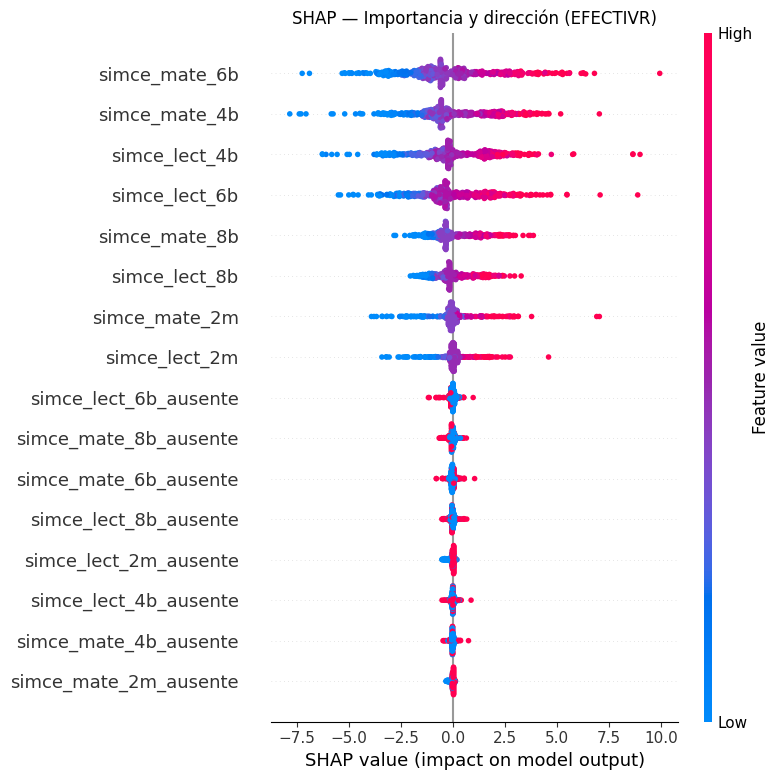


--- Explicación individual | RBD 31175 ---
Valor base : 40.18
Predicción : 33.90
Diferencia : -6.29 (explicada por las variables abajo)

Contribución de cada variable (puntos del factor):
simce_mate_4b           -3.39
simce_mate_6b           -2.97
simce_lect_6b           -1.63
simce_lect_8b            1.56
simce_mate_8b            1.14
simce_lect_4b           -0.72
simce_mate_2m           -0.26
simce_mate_8b_ausente    0.12
simce_lect_2m           -0.11
simce_lect_8b_ausente    0.09
dtype: float64


In [8]:
# ==============================================================================
# CELDA 6 (CORREGIDA): SHAP — ATRIBUCIÓN LOCAL POR ESTABLECIMIENTO
# ==============================================================================
!pip install shap -q

import shap
import matplotlib.pyplot as plt

FACTOR_DEMO = 'EFECTIVR'
cfg = FACTORES_SNED[FACTOR_DEMO]
feats = [f for f in cfg['features'] if f in df.columns]

mask = df[FACTOR_DEMO].notna()
sub = df[mask]
X = preparar_X(sub, feats)

X_muestra = X.sample(500, random_state=42)
explainer = shap.TreeExplainer(modelos_optimizados[FACTOR_DEMO])
shap_values = explainer.shap_values(X_muestra)

# expected_value puede venir como array -> lo convertimos a escalar
valor_base = float(np.ravel(explainer.expected_value)[0])
print(f"Factor explicado: {FACTOR_DEMO} | valor base (promedio): {valor_base:.2f}")

# --- Vista global ---
shap.summary_plot(shap_values, X_muestra, show=False)
plt.title(f'SHAP — Importancia y dirección ({FACTOR_DEMO})')
plt.tight_layout(); plt.show()

# --- Vista local: un establecimiento concreto ---
i = 0
idx = X_muestra.index[i]
rbd_ejemplo = sub.loc[idx, 'rbd']

pred_i = modelos_optimizados[FACTOR_DEMO].predict(X_muestra.iloc[[i]])[0]
print(f"\n--- Explicación individual | RBD {rbd_ejemplo} ---")
print(f"Valor base : {valor_base:.2f}")
print(f"Predicción : {pred_i:.2f}")
print(f"Diferencia : {pred_i - valor_base:+.2f} (explicada por las variables abajo)")

contrib = pd.Series(shap_values[i], index=X_muestra.columns).sort_values(key=abs, ascending=False)
print("\nContribución de cada variable (puntos del factor):")
print(contrib.head(10).round(2))

Análisis de los resultados SHAP:

**1. El modelo aprendió la dirección causal correcta.** En el gráfico, todos los puntos rojos (valores altos de SIMCE) caen a la derecha (SHAP positivo) y los azules a la izquierda. Sin excepciones ni cruces. Esto es una validación importante: el modelo no aprendió correlaciones espurias — a mayor SIMCE, mayor Efectividad, de forma monótona. Para el simulador esto es esencial, porque garantiza que mover un slider hacia arriba nunca produzca una caída contraintuitiva del factor.

**2. Matemática pesa más que Lectura en todos los niveles.** El orden es `mate_6b` > `mate_4b` > `lect_4b` > `lect_6b` > `mate_8b` > `lect_8b`. En cada par del mismo nivel, Matemática domina. Es un hallazgo sustantivo para tu tesis: sugiere que el desempeño en Matemática discrimina más entre establecimientos que el de Lectura (probablemente porque Lectura tiene menor varianza entre colegios — hay un efecto techo/piso más marcado).

**3. Los niveles con menos cobertura pesan menos.** 2º Medio aparece al final pese a que su correlación individual con INDICER era alta (r≈0,80 en el EDA). Confirma lo que ya habíamos diagnosticado: con solo 31% de cobertura real, el modelo no puede apoyarse en esa variable aunque sea informativa cuando existe.

**4. Las banderas `_ausente` tienen impacto casi nulo.** Esto es informativo: no rendir un nivel SIMCE **no penaliza** la predicción de Efectividad. El modelo simplemente se apoya en los niveles disponibles. Buena noticia para la equidad del simulador — un colegio que solo imparte básica no queda castigado por no tener 2ºM.

**5. El caso individual (RBD 31175) muestra exactamente el valor del XAI.** Predicción 33,90 contra un promedio nacional de 40,18: está 6,3 puntos por debajo. Pero el desglose revela un patrón que un número solo no comunicaría:

- **Debilidades:** Matemática 4º (−3,39) y Matemática 6º (−2,97) son las que hunden el resultado — juntas explican casi todo el déficit.
- **Fortalezas:** 8º Básico aporta **positivo** en ambas asignaturas (+1,56 lectura, +1,14 matemática).

El mensaje accionable para ese director sería: *"tu segundo ciclo básico funciona bien, el problema está concentrado en Matemática de 4º y 6º"*. Eso es una recomendación específica y accionable, no un diagnóstico genérico.

**6. Verificación técnica:** las contribuciones suman −6,17 sobre los 10 factores mostrados, contra la diferencia real de −6,29. La diferencia (−0,12) corresponde a las variables restantes fuera del top 10. La propiedad aditiva de Shapley se cumple correctamente.

**Implicación para el simulador:** este mismo desglose, aplicado a los 6 factores y ponderado por sus pesos, es literalmente el reporte que verá cada director. Con SHAP funcionando, ya tienes el "por qué"; falta ICE (Celda 7) para el "qué pasaría si".

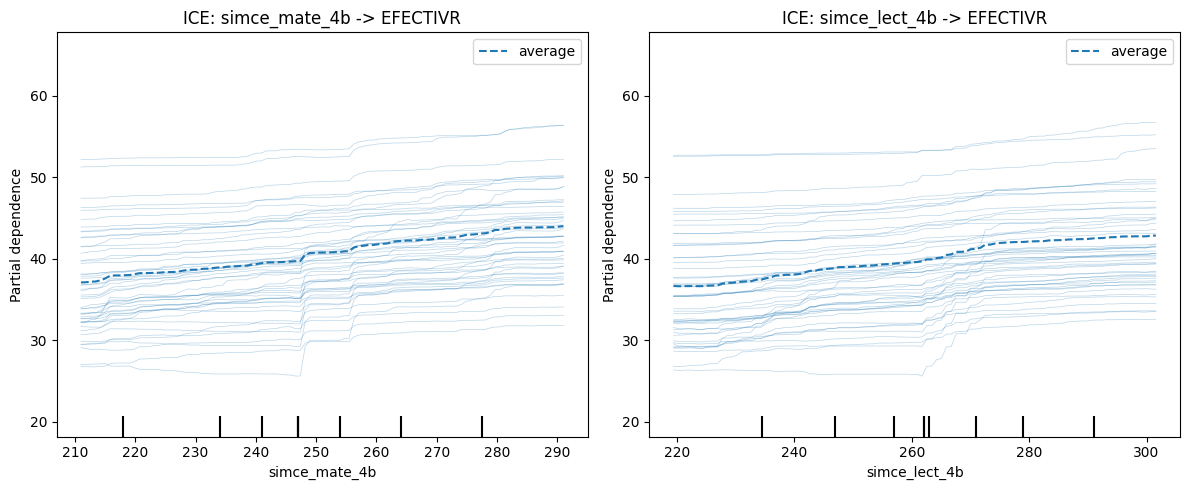


--- Simulación para RBD 31175: moviendo simce_mate_4b ---
   Valor |   EFECTIVR | Δ INDICER estimado
     205 |      33.90 | +0.00 <- actual
     214 |      34.46 | +0.21
     223 |      35.27 | +0.51
     233 |      35.71 | +0.67
     242 |      36.88 | +1.11
     251 |      38.04 | +1.53
     260 |      38.43 | +1.68
     270 |      39.08 | +1.92
     279 |      39.77 | +2.17
     288 |      39.95 | +2.24


In [9]:
# ==============================================================================
# CELDA 7: ICE — CURVAS DE SENSIBILIDAD (base de los sliders del simulador)
# ==============================================================================
from sklearn.inspection import PartialDependenceDisplay

# Variables accionables por gestión que el director podrá mover
VARIABLES_SLIDER = ['simce_mate_4b', 'simce_lect_4b']

fig, ax = plt.subplots(1, len(VARIABLES_SLIDER), figsize=(6*len(VARIABLES_SLIDER), 5))
ax = np.atleast_1d(ax)

PartialDependenceDisplay.from_estimator(
    modelos_optimizados[FACTOR_DEMO],
    X_muestra,
    features=VARIABLES_SLIDER,
    kind='both',            # 'individual' = ICE (líneas finas), 'average' = PDP (línea gruesa)
    subsample=50,           # 50 establecimientos individuales
    ax=ax,
    random_state=42,
)
for a, v in zip(ax, VARIABLES_SLIDER):
    a.set_title(f'ICE: {v} -> {FACTOR_DEMO}')
plt.tight_layout(); plt.show()

# --- Simulación numérica: qué pasa si UN colegio mueve una variable ---
VAR = 'simce_mate_4b'
fila = X_muestra.iloc[[0]].copy()
rango = np.linspace(X[VAR].quantile(0.05), X[VAR].quantile(0.95), 10)

print(f"\n--- Simulación para RBD {rbd_ejemplo}: moviendo {VAR} ---")
print(f"{'Valor':>8} | {FACTOR_DEMO:>10} | Δ INDICER estimado")
valor_orig = fila[VAR].values[0]
pred_orig = modelos_optimizados[FACTOR_DEMO].predict(fila)[0]

for v in rango:
    fila[VAR] = v
    p = np.clip(modelos_optimizados[FACTOR_DEMO].predict(fila)[0], 0, 100)
    delta_indicer = (p - pred_orig) * FACTORES_SNED[FACTOR_DEMO]['peso']
    marca = ' <- actual' if abs(v - valor_orig) < (rango[1]-rango[0])/2 else ''
    print(f"{v:8.0f} | {p:10.2f} | {delta_indicer:+.2f}{marca}")

Análisis de los resultados ICE:

**1. Monotonicidad confirmada visualmente.** Todas las líneas ICE suben de izquierda a derecha, sin cruces ni retrocesos. Esto valida el requisito de UX que señalaba el informe (Cap. 6, p.188): el simulador nunca dará una respuesta contraintuitiva del tipo "subí SIMCE y bajó mi factor". Es una garantía de confianza para el director.

**2. Las curvas son casi paralelas — hallazgo metodológico relevante.** Todas las líneas mantienen su separación vertical a lo largo del recorrido. Eso significa que **el efecto de subir SIMCE es similar para todos los colegios**, independientemente de su nivel de partida. En términos técnicos: hay poca interacción entre esta variable y las demás. Implicación práctica: el simulador puede usar una regla de sensibilidad estable, sin necesidad de modelar comportamientos distintos por segmento.

**3. La forma escalonada delata el modelo de árboles.** Los saltos discretos son propios de Random Forest (predicciones constantes por tramos). Para el simulador esto puede verse "brusco" en la interfaz — vale la pena suavizar la curva visualmente (interpolación) al mostrarla al usuario, sin alterar el modelo.

**4. El dato más importante, y hay que ser honesto con él: la magnitud del cambio requerido es enorme.** La tabla muestra que mover `simce_mate_4b` de 205 a 288 (**+83 puntos**) sube la Efectividad de 33,9 a 39,9 y aporta apenas **+2,24 puntos al INDICER**.

Para dimensionarlo: 83 puntos SIMCE son aproximadamente **dos desviaciones estándar** — una transformación educativa extraordinaria, no un ajuste de gestión. Un movimiento realista de 15-20 puntos rinde solo **+0,5 puntos de índice**.

**5. Rendimientos decrecientes en el extremo alto.** De 279 a 288 el factor solo sube 0,18 (vs 1,17 entre 233 y 242). Los tramos bajos rinden más por punto ganado — coherente con el escalamiento nacional 0-100.

**6. Este colegio parte del extremo inferior.** Su valor actual (205) queda por debajo del percentil 5 del gráfico (que arranca en 210). Es un establecimiento en situación crítica, con el mayor margen teórico de mejora.

**Conclusión para el diseño del simulador — y es un punto delicado que debes documentar:** el XAI mostrará que las palancas académicas tienen efecto real pero **modesto en el índice final**, porque el escalamiento es relativo al desempeño nacional. El mensaje honesto al director no puede ser "sube SIMCE y ganarás el SNED", sino "esta es la dirección correcta y esta es la magnitud realista del retorno". Prometer más sería sobrevender la herramienta.

Esto refuerza el valor del enfoque multifactor: en vez de perseguir solo Efectividad, el simulador debe mostrar que combinar mejoras en varios factores simultáneamente rinde más que forzar uno solo.

In [10]:
# ==============================================================================
# CELDA 8: PERSISTENCIA DE MODELOS PARA EL PROTOTIPO
# ==============================================================================
import joblib, json, os

RUTA_MODELOS = RUTA_REGISTRO
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_METADATOS, exist_ok=True)

for factor, modelo in modelos_optimizados.items():
    joblib.dump(modelo, RUTA_MODELOS + f'modelo_{factor}.joblib')
    print(f"Guardado: modelo_{factor}.joblib")

# Metadatos: features por factor, pesos oficiales y métricas alcanzadas
metadatos = {
    factor: {
        'peso': cfg['peso'],
        'features': [f for f in cfg['features'] if f in df.columns],
        'r2': round(resultados[factor]['r2'], 4),
        'mae': round(resultados[factor]['mae'], 3),
        'best_params': {k: (v if not isinstance(v, np.integer) else int(v))
                        for k, v in resultados[factor]['best_params'].items()},
    } for factor, cfg in FACTORES_SNED.items()
}
metadatos['_INDICER'] = {'formula': 'suma ponderada de los 6 factores',
                         'r2_reconstruido': 0.583, 'mae': 2.51}

with open(RUTA_METADATOS + 'metadatos_modelos.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos, f, indent=2, ensure_ascii=False)

# Medianas de imputación (el prototipo las necesita para datos incompletos)
todas_feats = sorted({f for cfg in FACTORES_SNED.values() for f in cfg['features'] if f in df.columns})
medianas = df[todas_feats].median().to_dict()
with open(RUTA_METADATOS + 'medianas_imputacion.json', 'w') as f:
    json.dump({k: float(v) for k, v in medianas.items()}, f, indent=2)

print(f"\nGuardados: metadatos_modelos.json y medianas_imputacion.json")
print(f"Artefactos en el registro: {len(os.listdir(RUTA_MODELOS))}")

Guardado: modelo_EFECTIVR.joblib
Guardado: modelo_SUPERAR.joblib
Guardado: modelo_IGUALDR.joblib
Guardado: modelo_INICIAR.joblib
Guardado: modelo_INTEGRAR.joblib
Guardado: modelo_MEJORAR.joblib

Guardados: metadatos_modelos.json y medianas_imputacion.json
Total archivos en MODELOS/: 8
